In [1]:
#This notebook generates the ann-based figures that comprise Figure 3 in the paper

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par

resolutions=['1x', '2x', '4e-3x']

#colors from seaborn's colorblind palette
#-----------------------------------------------
color_data=sns.color_palette("colorblind")[7]
color_noise=sns.color_palette("colorblind")[7]


colors={'4e-3x':['#fee0d2', '#deebf7'],
       '2x':['#fc9272', '#9ecae1'],
       '1x':['#de2d26', '#3182bd'] }

color_ann=colors['1x'][0]
color_bms=colors['1x'][1]
#-----------------------------------------------

In [91]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,dimensions=False ):
    
    #Two-dimensional (only nguyen n=10) or one-dimensional functions
    if dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #Discriminate ann-generated vs nugyen functions
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
        
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Errors approximation
#------------------------------------------------------
def get_approximation_errors(resolution):
    #read errors
    errors_approximation=pd.read_csv('../data/'+ 'errors_approximation_' + resolution +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test", "n", "r"]
    errors_approximation=errors_approximation[columns]

    #divide between train/test
    #----------------------------------------------------------------------------------------------------------------------
    errors_approximation_train=errors_approximation[["sigma","function", "rmse_nn_train", "rmse_mdl_train","n", "r"]]
    errors_approximation_train=errors_approximation_train.rename(columns={"rmse_nn_train": "rmse ann", "rmse_mdl_train": "rmse mdl"})
    errors_approximation_train=pd.melt(errors_approximation_train,id_vars=["sigma","function", "n", "r"], 
                                       var_name="error train",value_name= "value train")   

    errors_approximation_test=errors_approximation[["sigma","function", "rmse_nn_test", "rmse_mdl_test","n", "r"]]
    errors_approximation_test=errors_approximation_test.rename(columns={"rmse_nn_test": "rmse ann", "rmse_mdl_test": "rmse mdl"})
    errors_approximation_test=pd.melt(errors_approximation_test,id_vars= ["sigma","function", "n", "r"], var_name="error test", 
                                      value_name= "value test")
    #----------------------------------------------------------------------------------------------------------------------
    
    #Separate tanh and leaky ReLU
    errors_tanh_train=errors_approximation_train[errors_approximation_train['function']=='tanh']
    errors_tanh_test=errors_approximation_test[errors_approximation_test['function']=='tanh']

    errors_leaky_train=errors_approximation_train[errors_approximation_train['function']=='leaky_ReLU']
    errors_leaky_test=errors_approximation_test[errors_approximation_test['function']=='leaky_ReLU']

    return errors_tanh_train, errors_tanh_test, errors_leaky_train, errors_leaky_test
#------------------------------------------------------

#Errors of interpolation
#------------------------------------------------------
def get_interpolation_errors(resolution):
    #read errors
    errors_inter_extrapolation=pd.read_csv('../data/'+ 'errors_interpolation_' + resolution +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.", "n", "r"]
    errors_inter_extrapolation=errors_inter_extrapolation[columns]

    #divide between inter/extrapolation
    #----------------------------------------------------------------------------------------------------------------------
    errors_interpolation=errors_inter_extrapolation[["sigma","function", "rmse_nn_interp.", "rmse_mdl_interp.","n", "r"]]
    #change column names for readability of legend
    errors_interpolation=errors_interpolation.rename(columns={"rmse_nn_interp.": "rmse ann", "rmse_mdl_interp.": "rmse mdl"})
    errors_interpolation=pd.melt(errors_interpolation,id_vars=["sigma","function", "n", "r"], var_name="error interp.",
                                 value_name= "value interp.")   


    errors_extrapolation=errors_inter_extrapolation[["sigma","function", "rmse_nn_extrap.", "rmse_mdl_extrap.","n", "r"]]
    #change column names for readability of legend
    errors_extrapolation=errors_extrapolation.rename(columns={"rmse_nn_extrap.": "rmse ann", "rmse_mdl_extrap.": "rmse mdl"})
    errors_extrapolation=pd.melt(errors_extrapolation,id_vars= ["sigma","function", "n", "r"], var_name="error extrap.", 
                                 value_name= "value extrap.")

    #----------------------------------------------------------------------------------------------------------------------
    
    #Separate tanh and leaky ReLU
    errors_t_tr=errors_interpolation[errors_interpolation['function']=='tanh']
    errors_t_tt=errors_extrapolation[errors_extrapolation['function']=='tanh']

    errors_l_tr=errors_interpolation[errors_interpolation['function']=='leaky_ReLU']
    errors_l_tt=errors_extrapolation[errors_extrapolation['function']=='leaky_ReLU']

    return errors_t_tr, errors_t_tt, errors_l_tr, errors_l_tt
#------------------------------------------------------


#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/paper_figures/figure3_ann/'      
extensions=['.svg', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 16*cm; height=16*cm 
#--------------------------------

#Text sizes  
#--------------------------------
size_axis=16;size_ticks=14;
size_title=16;size_legend=14
line_w=3;marker_data=6;#m_size=6
m_size=10
#--------------------------------

#Individual figures
#-----------------------------------
xmin_1=-2.05 ;xmax_1=2.05
ymin_1=-0.15 ;ymax_1=1.1

xtick_labels_1=[-2, -1, 0, 1, 2 ];ytick_labels_1=[ 0, 0.5, 1.0]
#-----------------------------------

#Approximations, interpolations, extrapolations
#--------------------------------
markers = {'rmse_nn': 'o', 'rmse_mdl': 's'};
xtick_labels=np.arange(0.0,0.22,0.04)

resamples=100000; bs_seed=1111
ymin=1e-4;ymax=1.15
#--------------------------------


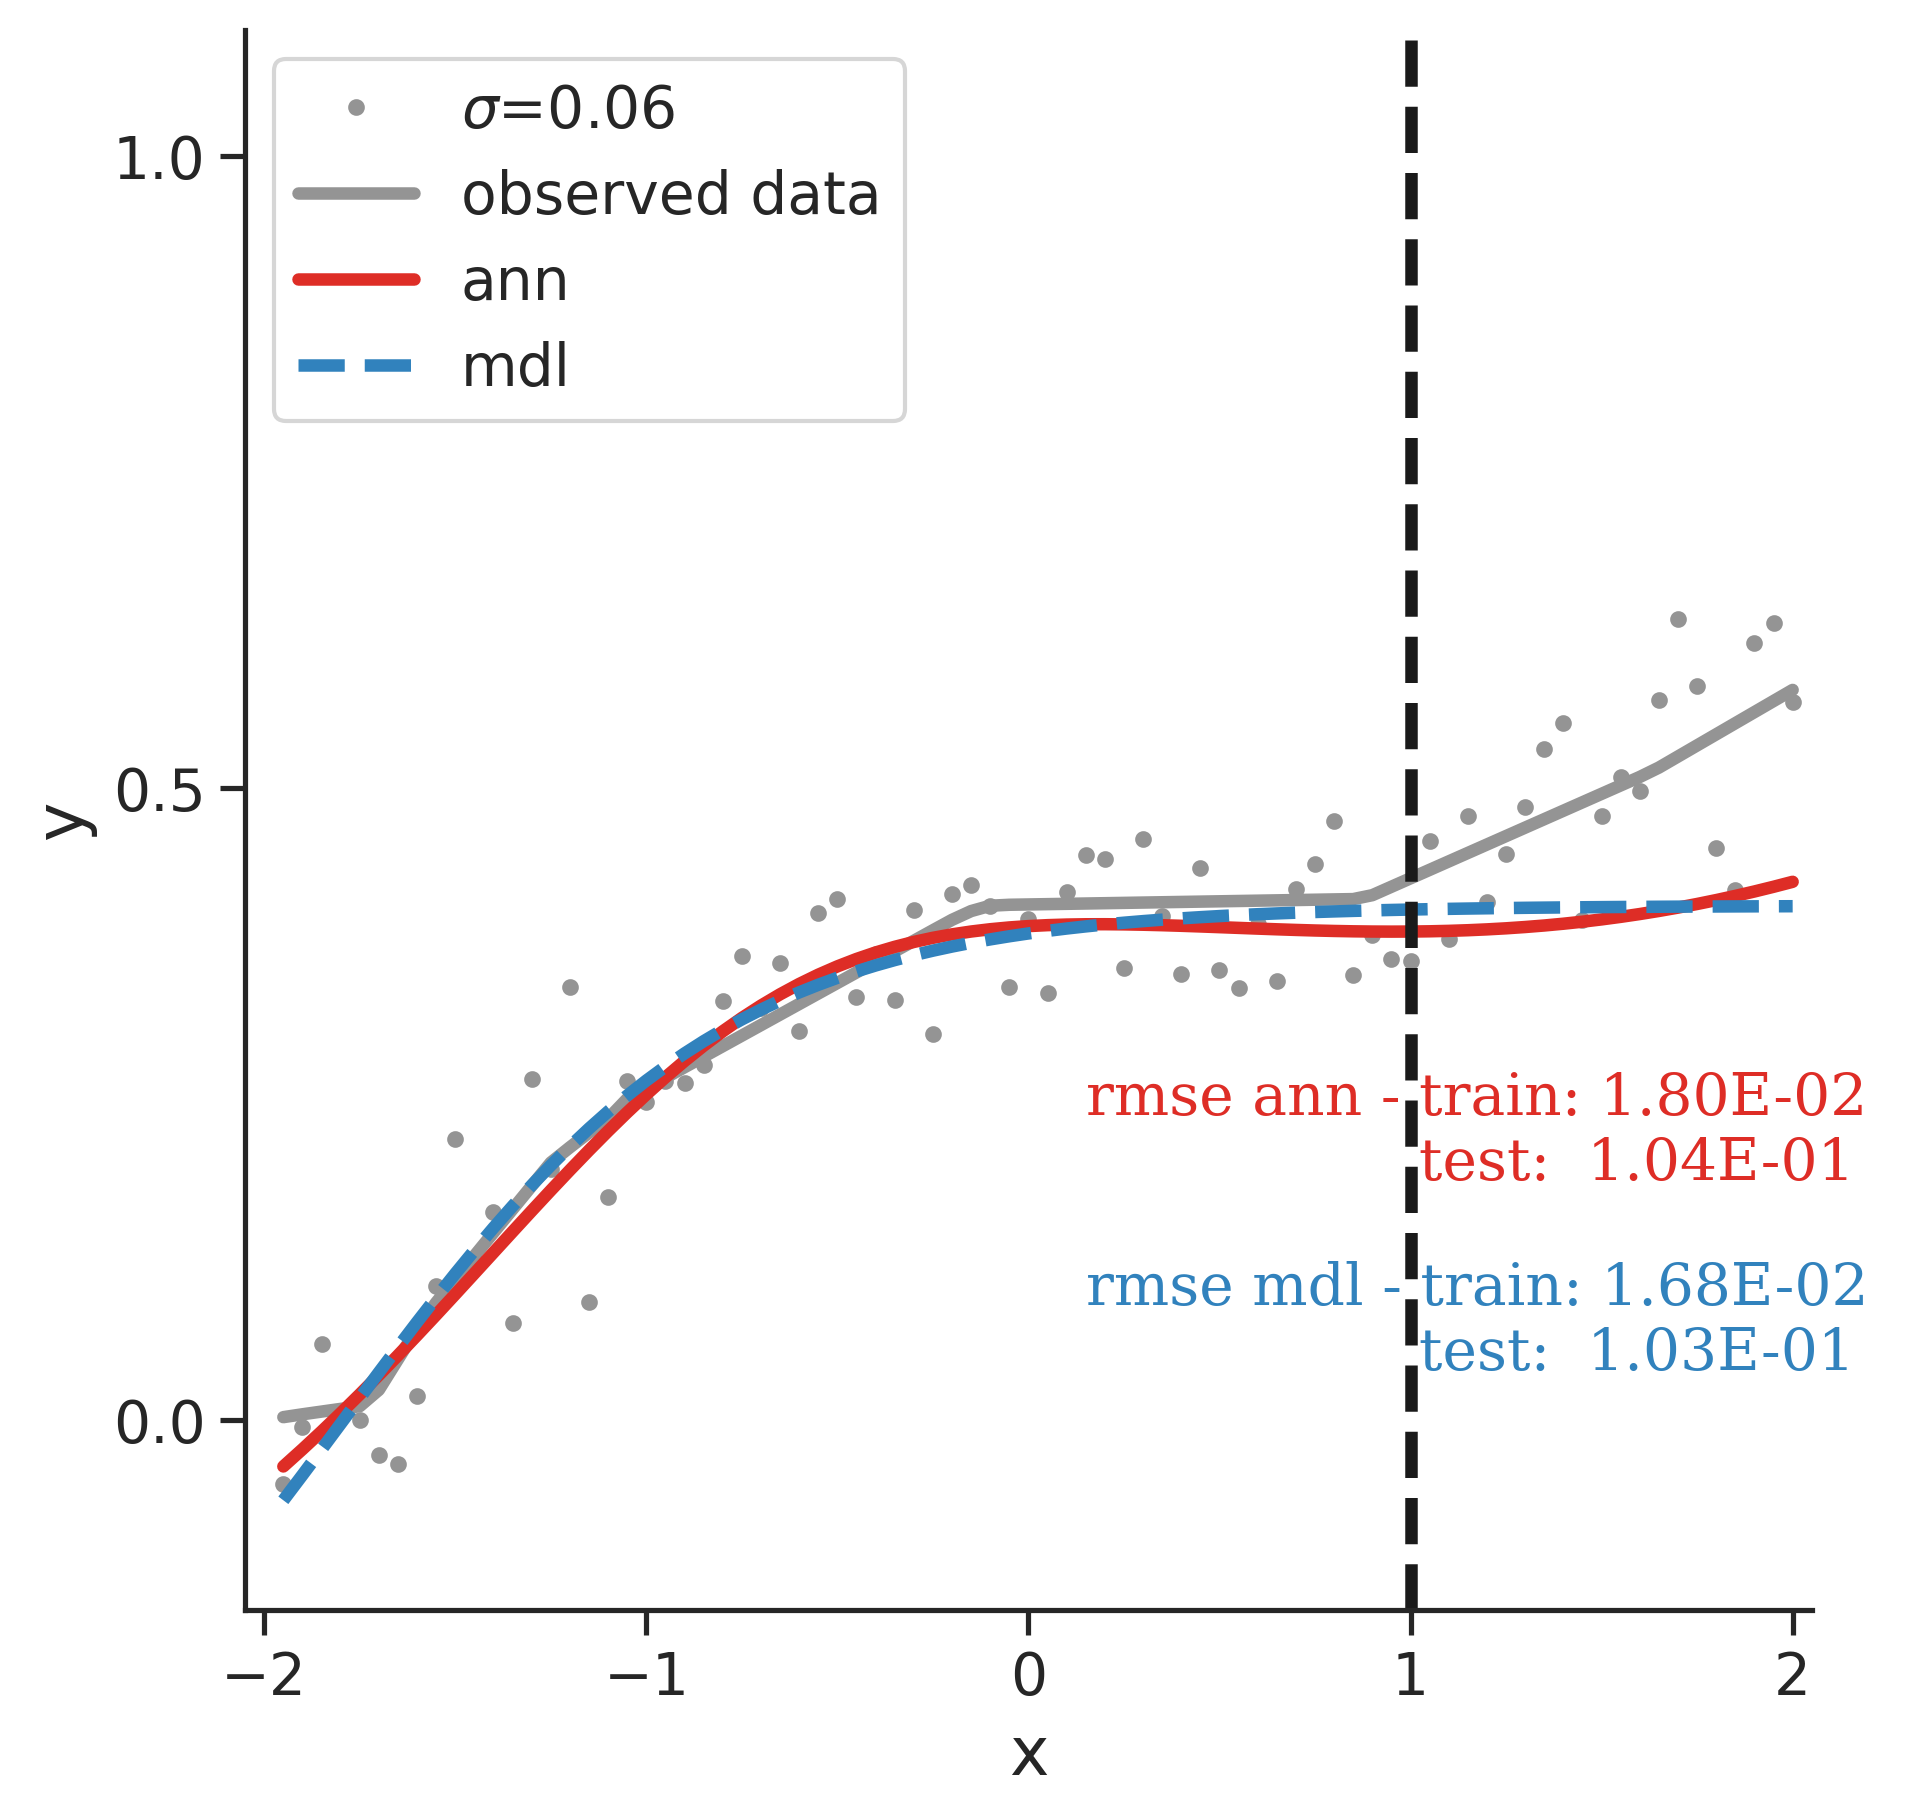

In [113]:
#Plot single tanh figure
NPAR=10;steps=50000

resolution='1x' #'0.5x', '1x', '2x', '4e-3'
resolutions={'1x':'0.05' , '2x': '0.025' , '4e-3x':'0.004' }


#function='tanh';       n=4; sigma=0.04; realization=0
function='leaky_ReLU'; n=6; sigma=0.06; realization=2

#Read NN data
nn_path='../data/nns/' + resolution + '_resolution/approximation/'
file_model='NN_no_overfit_' + function + '_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'

model_d= nn_path + file_model
d=pd.read_csv(model_d,index_col=0)
dn=d[d['rep']==n];dn=dn.reset_index(drop=True)


#Read BMS trace
bms_path='../data/MSTraces/' + resolution + '_resolution/'
filename='BMS_'+function+'_n_'+str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_' + resolutions[resolution] + '_trace_'+\
                str(steps)+'_prior_'+str(NPAR)+ '.csv'

trace=pd.read_csv(bms_path + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
#-------------------------
t,x,y=get_mdl(dn, trace)
#-------------------------

#Validation and train borders
n_points=int(len(dn.index))
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)
train_border=dn.loc[train_size_bms-1]['x1']

dplot = deepcopy(dn)
dplot['ybms'] = t.predict(x)

#compute errors
#ann errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ymodel'],dplot.loc[:train_size_bms -1]['y'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['ymodel'],dplot.loc[train_size_bms -1:]['y'])

#bms errors
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['y'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['y'])

fig=figure(figsize=(width,height), dpi=300) 

plt.plot(dn['x1'], dn['y_noise'],'.'  ,markersize=marker_data, linewidth=line_w, color=color_noise,label=r'$\sigma$=' + str(sigma) )
plt.plot(dn['x1'], dn['y'],linewidth=line_w, color=color_data,label='observed data')     
plt.plot(dn['x1'], dn['ymodel'] ,linewidth=line_w, color=color_ann,  label='ann')
plt.plot(dplot.x1, dplot.ybms   ,linewidth=line_w, color=color_bms, linestyle='--',label='mdl')

plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

#plt.title('$%s$' %  t.latex(), fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(xtick_labels_1, fontsize=size_ticks);plt.yticks(ytick_labels_1, fontsize=size_ticks)
sns.despine();plt.tight_layout()
plt.legend(loc='best', fontsize=size_legend)
#plt.text(-2.0, 0.65, 'rmse ann - train: %.2E \n                  test:  %.2E' % ( rmse_nn_train, rmse_nn_test), color=color_ann, fontsize=size_legend )
#plt.text(-2.0, 0.5,'rmse mdl - train: %.2E \n                  test:  %.2E' % (rmse_mdl_train, rmse_mdl_test), color=color_bms, fontsize=size_legend )

plt.text(0.15, 0.19, 'rmse ann - train: %.2E \n                  test:  %.2E' % ( rmse_nn_train, rmse_nn_test), \
         color=color_ann, fontsize=size_legend, fontname='serif')
plt.text(0.15, 0.04,'rmse mdl - train: %.2E \n                  test:  %.2E' % (rmse_mdl_train, rmse_mdl_test), \
         color=color_bms, fontsize=size_legend, fontname='serif' )


plt.xlim(xmin_1,xmax_1);plt.ylim(ymin_1,ymax_1)

name_fig='%s_%d_%.2f_%d' % (function, n, sigma, realization)
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#-------------------------------- 

In [98]:
# Initialize combined DataFrames for approximation
combined_tanh_train  = pd.DataFrame()
combined_tanh_test   = pd.DataFrame()
combined_leaky_train = pd.DataFrame()
combined_leaky_test  = pd.DataFrame()

# Initialize combined DataFrames for interpolation
combined_tanh_inter = pd.DataFrame()
combined_tanh_extra = pd.DataFrame()
combined_leaky_inter = pd.DataFrame()
combined_leaky_extra = pd.DataFrame()

# Load and combine data for each resolution
for resolution in resolutions:
    errors_tanh_train, errors_tanh_test, errors_leaky_train, errors_leaky_test = get_approximation_errors(resolution)
    errors_tanh_inter, errors_tanh_extra, errors_leaky_inter, errors_leaky_extra = get_interpolation_errors(resolution)
    
    # Add resolution identifier
    errors_tanh_train['resolution']  = resolution
    errors_tanh_test['resolution']   = resolution
    errors_leaky_train['resolution'] = resolution
    errors_leaky_test['resolution']  = resolution
    errors_tanh_inter['resolution']  = resolution

    errors_tanh_extra['resolution']  = resolution
    errors_leaky_inter['resolution'] = resolution
    errors_leaky_extra['resolution'] = resolution

    #Change column names to show number of points in legend
    points={'1x':'80' , '2x': '160' , '4e-3x':'1000' }
    errors_tanh_train['error train']=errors_tanh_train['error train'] + ': ' + points[resolution]
    errors_leaky_train['error train']=errors_leaky_train['error train'] + ': ' + points[resolution]
    errors_tanh_inter['error interp.']=errors_tanh_inter['error interp.'] + ': ' + points[resolution]
    errors_leaky_inter['error interp.']=errors_leaky_inter['error interp.'] + ': ' + points[resolution]
    errors_tanh_extra['error extrap.']=errors_tanh_extra['error extrap.'] + ': ' + points[resolution]
    errors_leaky_extra['error extrap.']=errors_leaky_extra['error extrap.'] + ': ' + points[resolution]
    
    # Combine DataFrames
    combined_tanh_train  = pd.concat([combined_tanh_train, errors_tanh_train])
    combined_tanh_test   = pd.concat([combined_tanh_test, errors_tanh_test])
    combined_leaky_train = pd.concat([combined_leaky_train, errors_leaky_train])
    combined_leaky_test  = pd.concat([combined_leaky_test, errors_leaky_test])

    combined_tanh_inter = pd.concat([combined_tanh_inter, errors_tanh_inter])
    combined_tanh_extra = pd.concat([combined_tanh_extra, errors_tanh_extra])

    combined_leaky_inter = pd.concat([combined_leaky_inter, errors_leaky_inter])
    combined_leaky_extra = pd.concat([combined_leaky_extra, errors_leaky_extra])


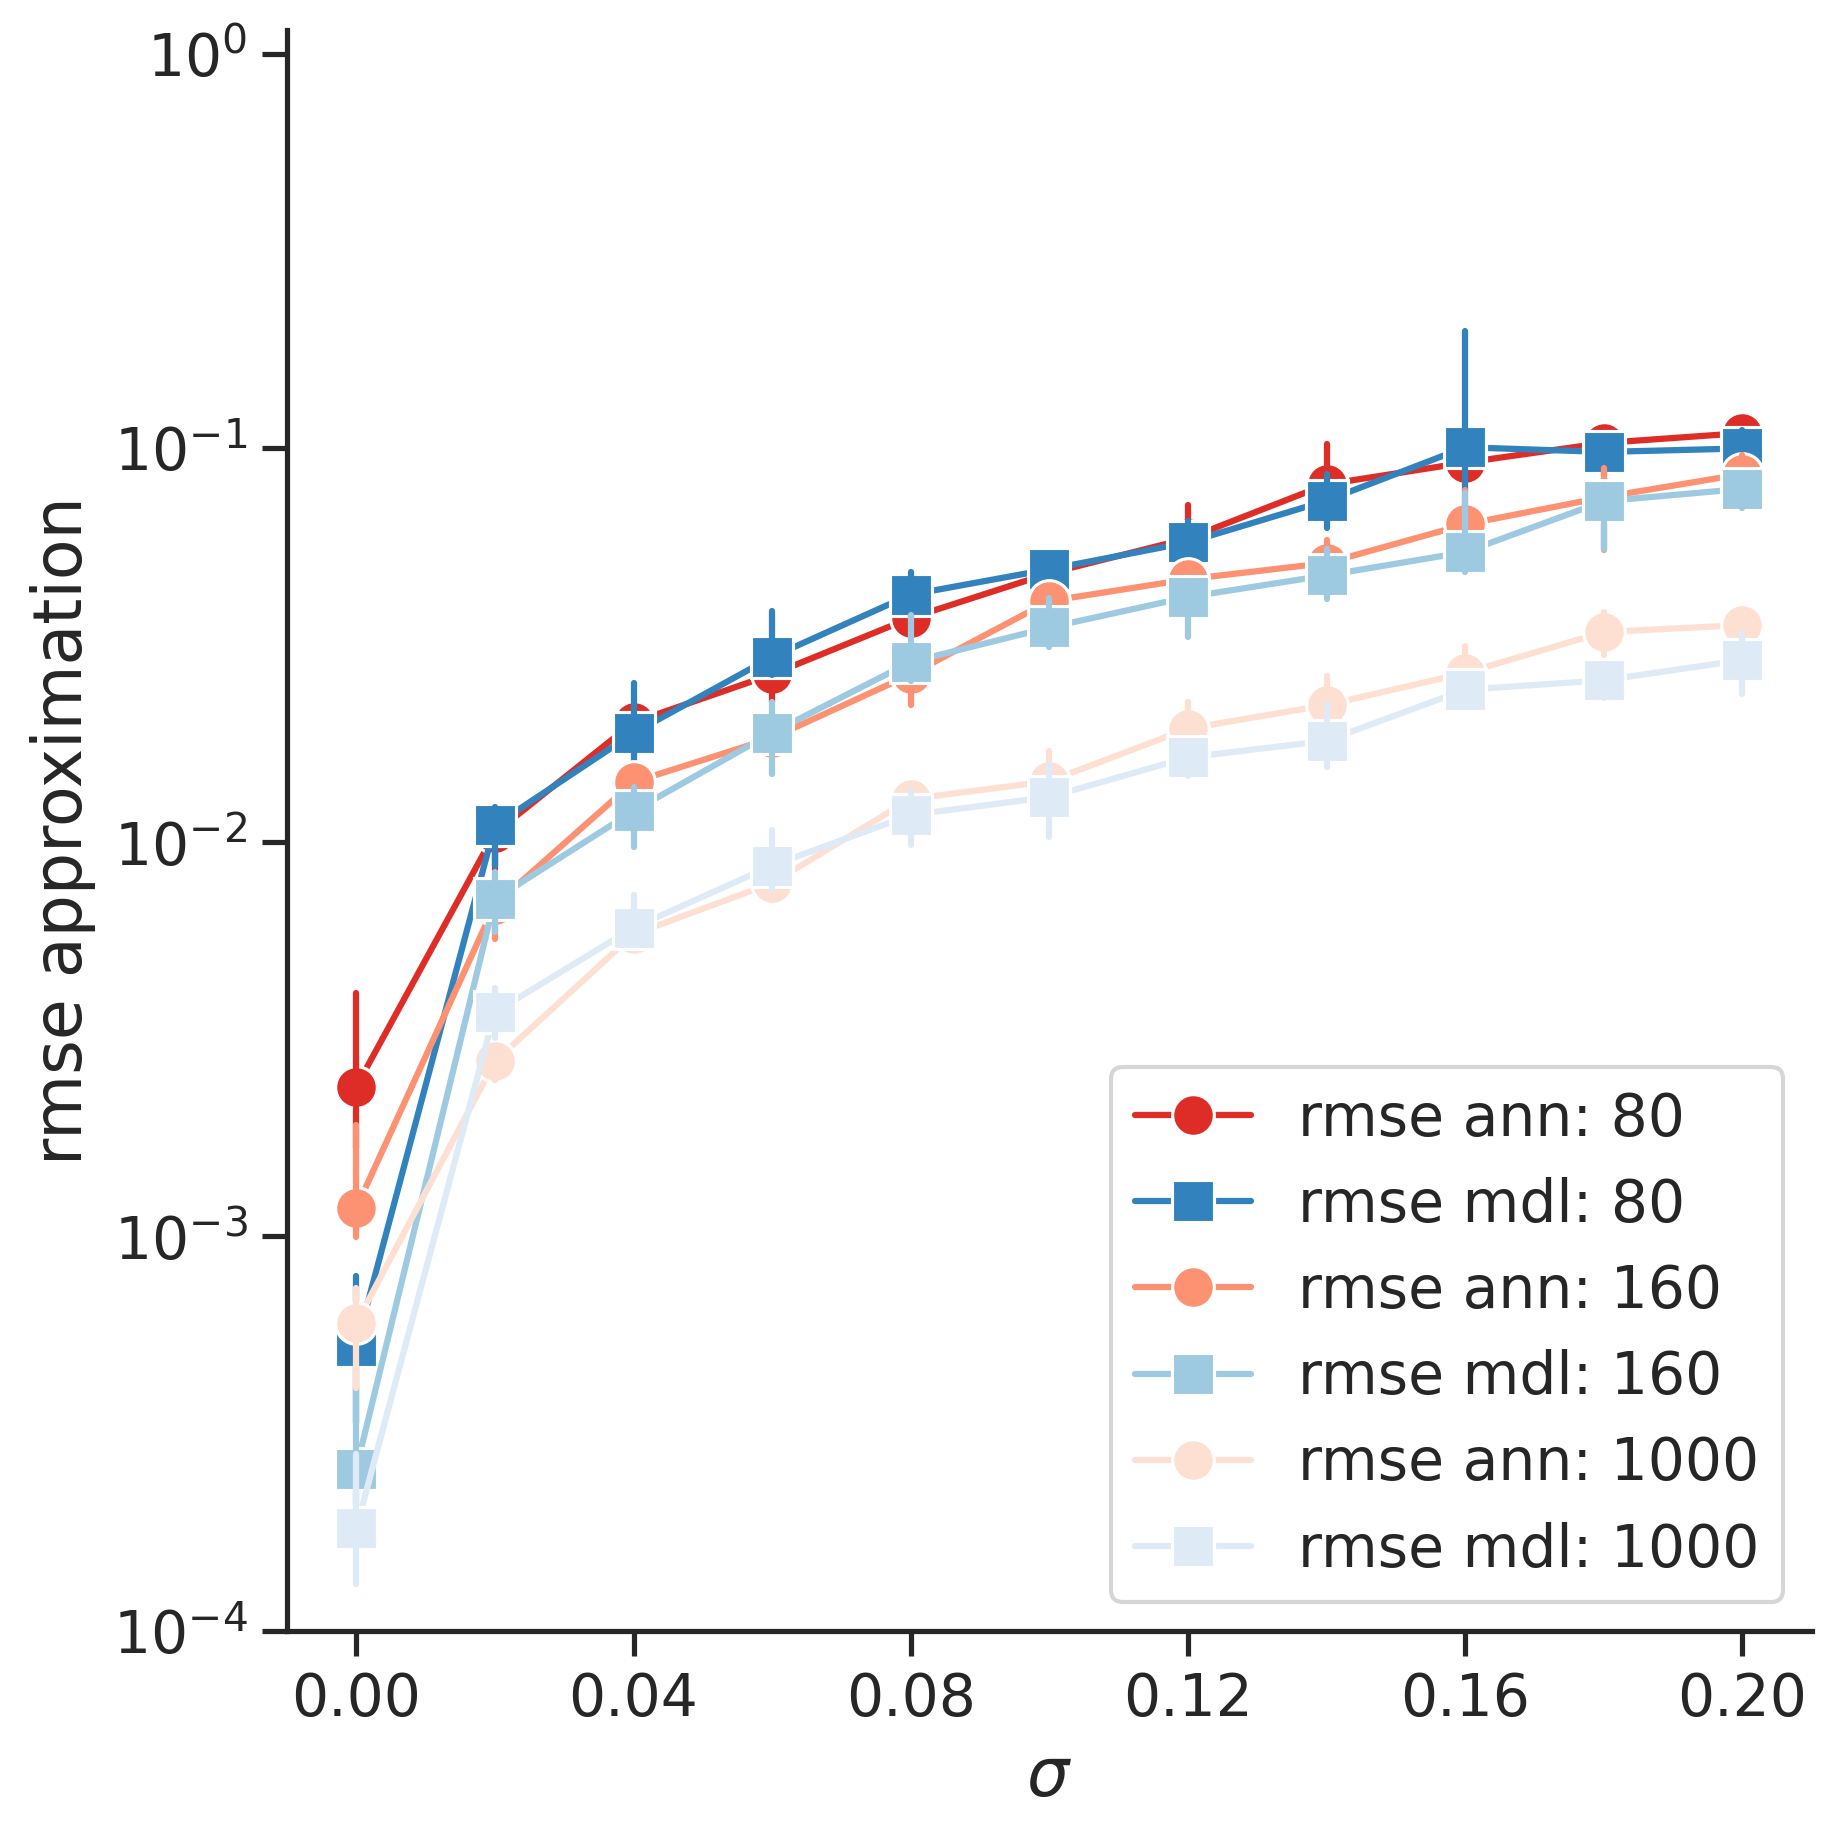

In [95]:
#Plot tanh approximations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_tanh_train[combined_tanh_train['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value train', hue='error train', style='error train',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=True, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse approximation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

plt.legend(loc='lower right', fontsize=size_legend)

name_fig='approximations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#------------------------------------------------------------------------------------------------------------------------

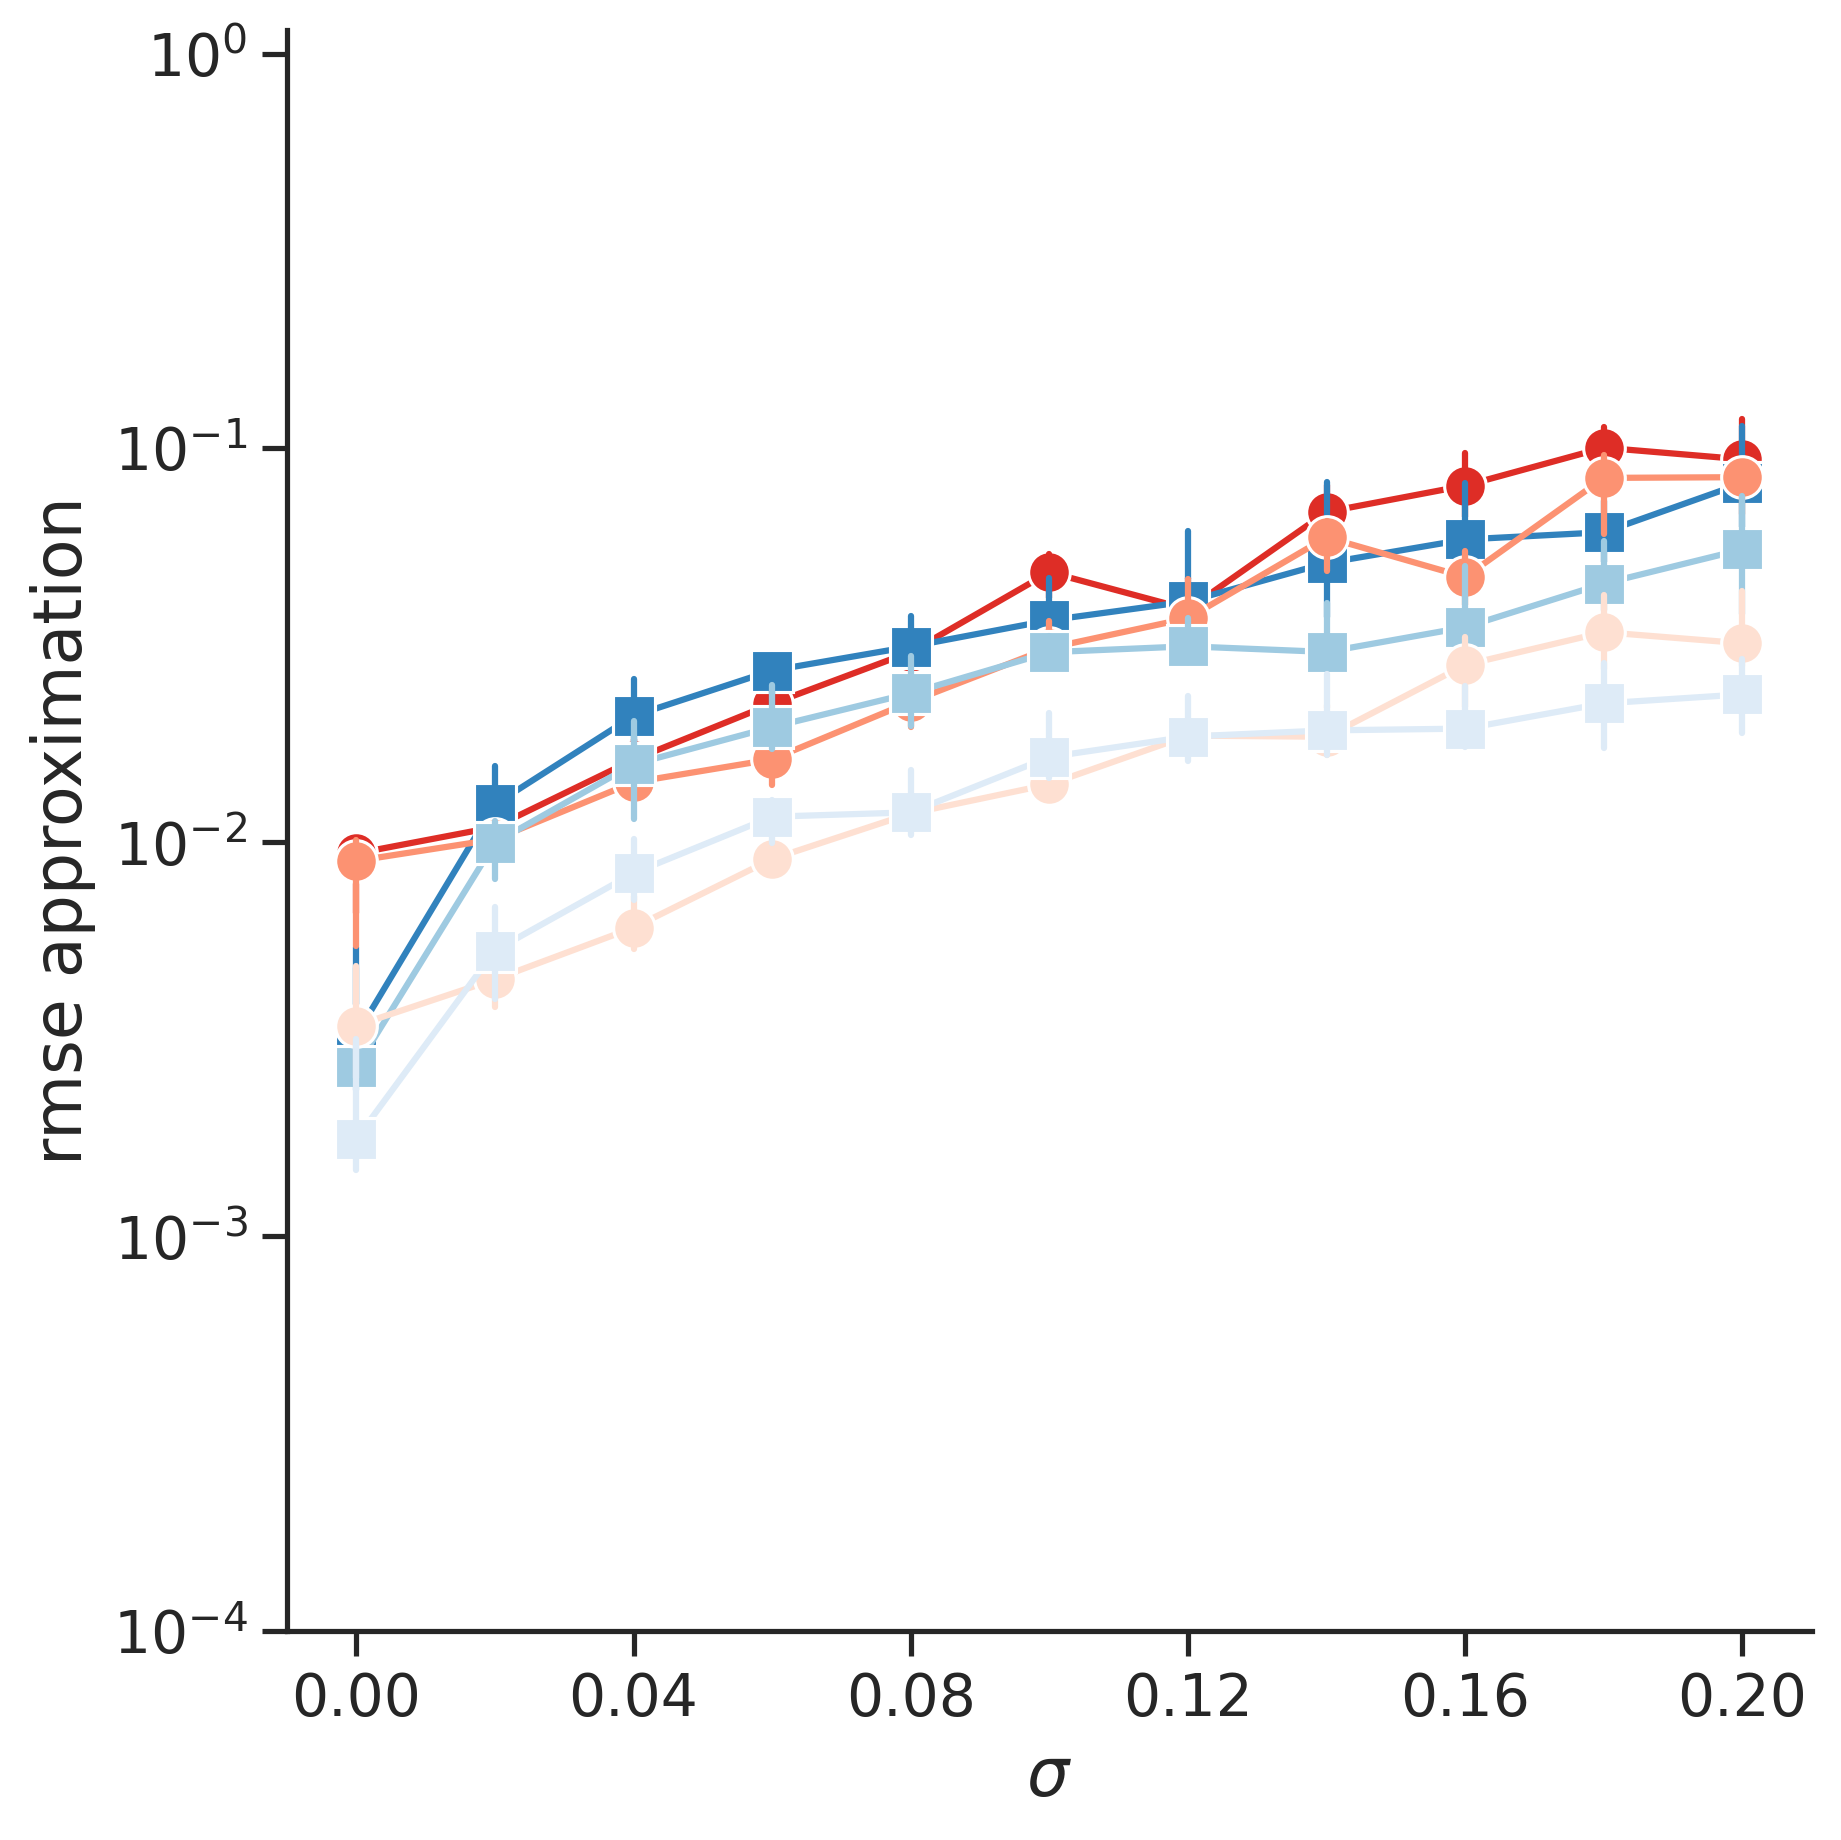

In [114]:
#Plot leaky approximations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_train[combined_leaky_train['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value train', hue='error train', style='error train',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse approximation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='approximations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

,sigma,function,n,r,error interp.,value interp.,resolution
0,0.0,tanh,0,0,rmse ann: 80,0.012386,1x
1,0.0,tanh,1,0,rmse ann: 80,0.012122,1x
2,0.0,tanh,2,0,rmse ann: 80,0.006643,1x
3,0.0,tanh,3,0,rmse ann: 80,0.001461,1x
4,0.0,tanh,4,0,rmse ann: 80,0.002459,1x
...,...,...,...,...,...,...,...
985,0.2,tanh,5,2,rmse mdl: 1000,0.037712,4e-3x
986,0.2,tanh,6,2,rmse mdl: 1000,0.034507,4e-3x
987,0.2,tanh,7,2,rmse mdl: 1000,0.019437,4e-3x
988,0.2,tanh,8,2,rmse mdl: 1000,0.022793,4e-3x


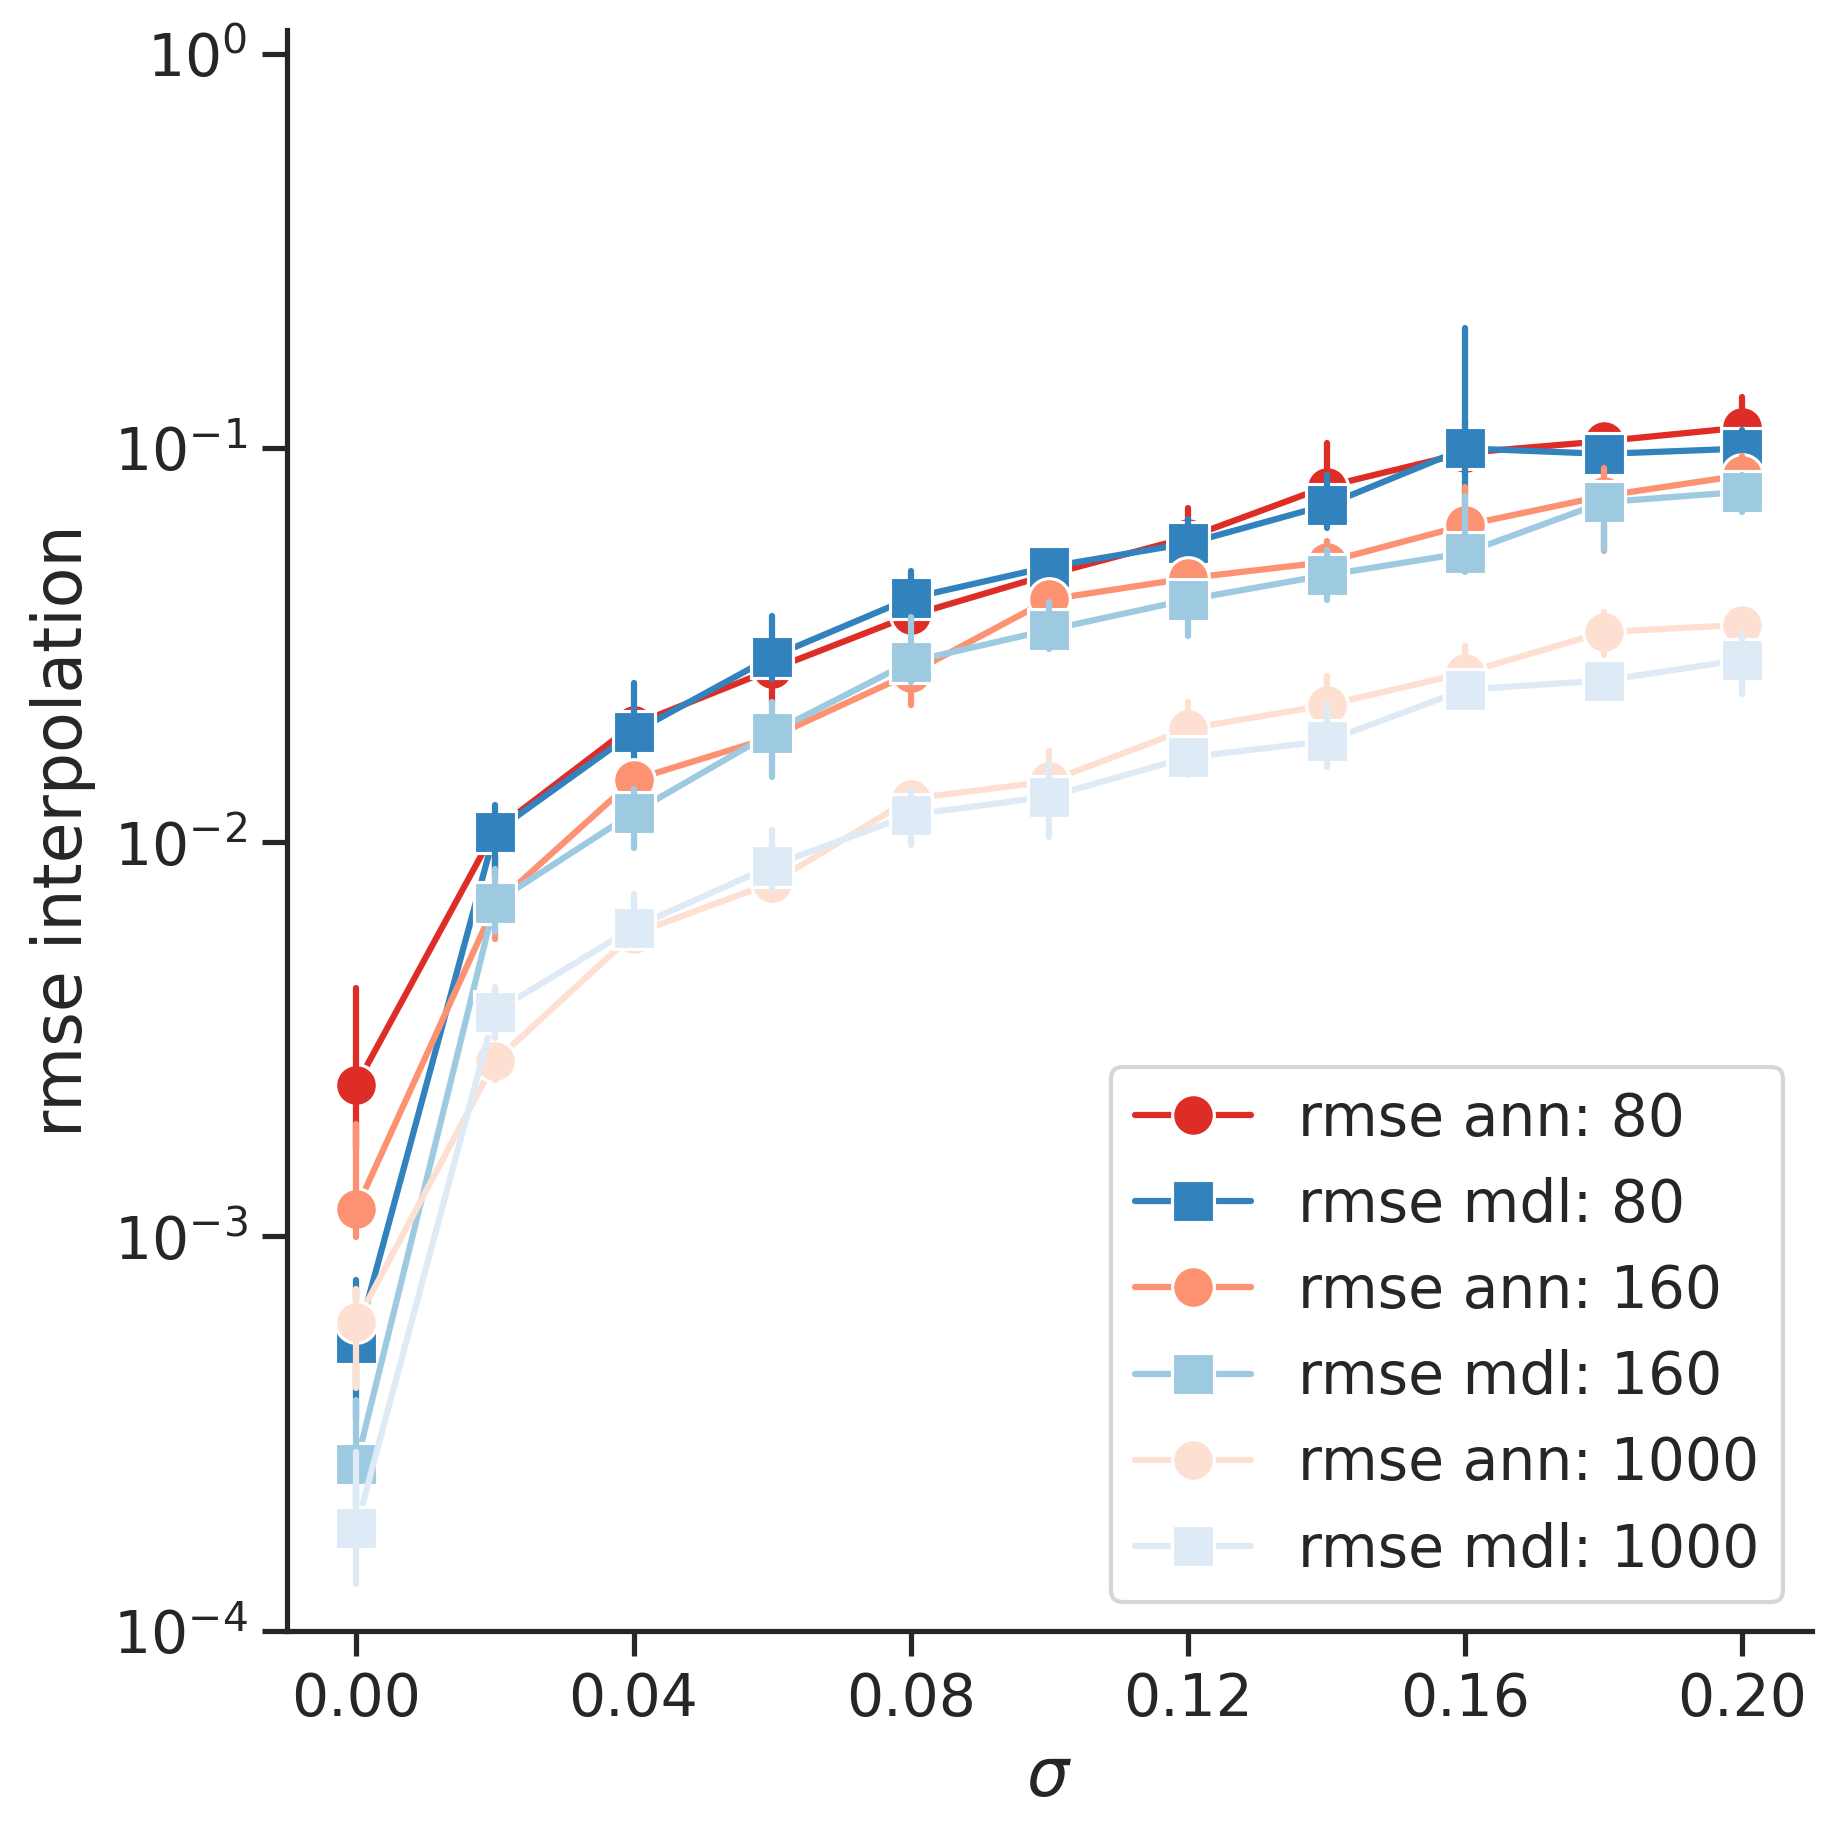

In [116]:
#Plot tanh interpolations
fig=figure(figsize=(width,height), dpi=300)

display(combined_tanh_inter)

for resolution in resolutions:
    data = combined_tanh_inter[combined_tanh_inter['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value interp.', hue='error interp.', style='error interp.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=True, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

plt.legend(loc='lower right', fontsize=size_legend)

name_fig='interpolations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#------------------------------------------------------------------------------------------------------------------------

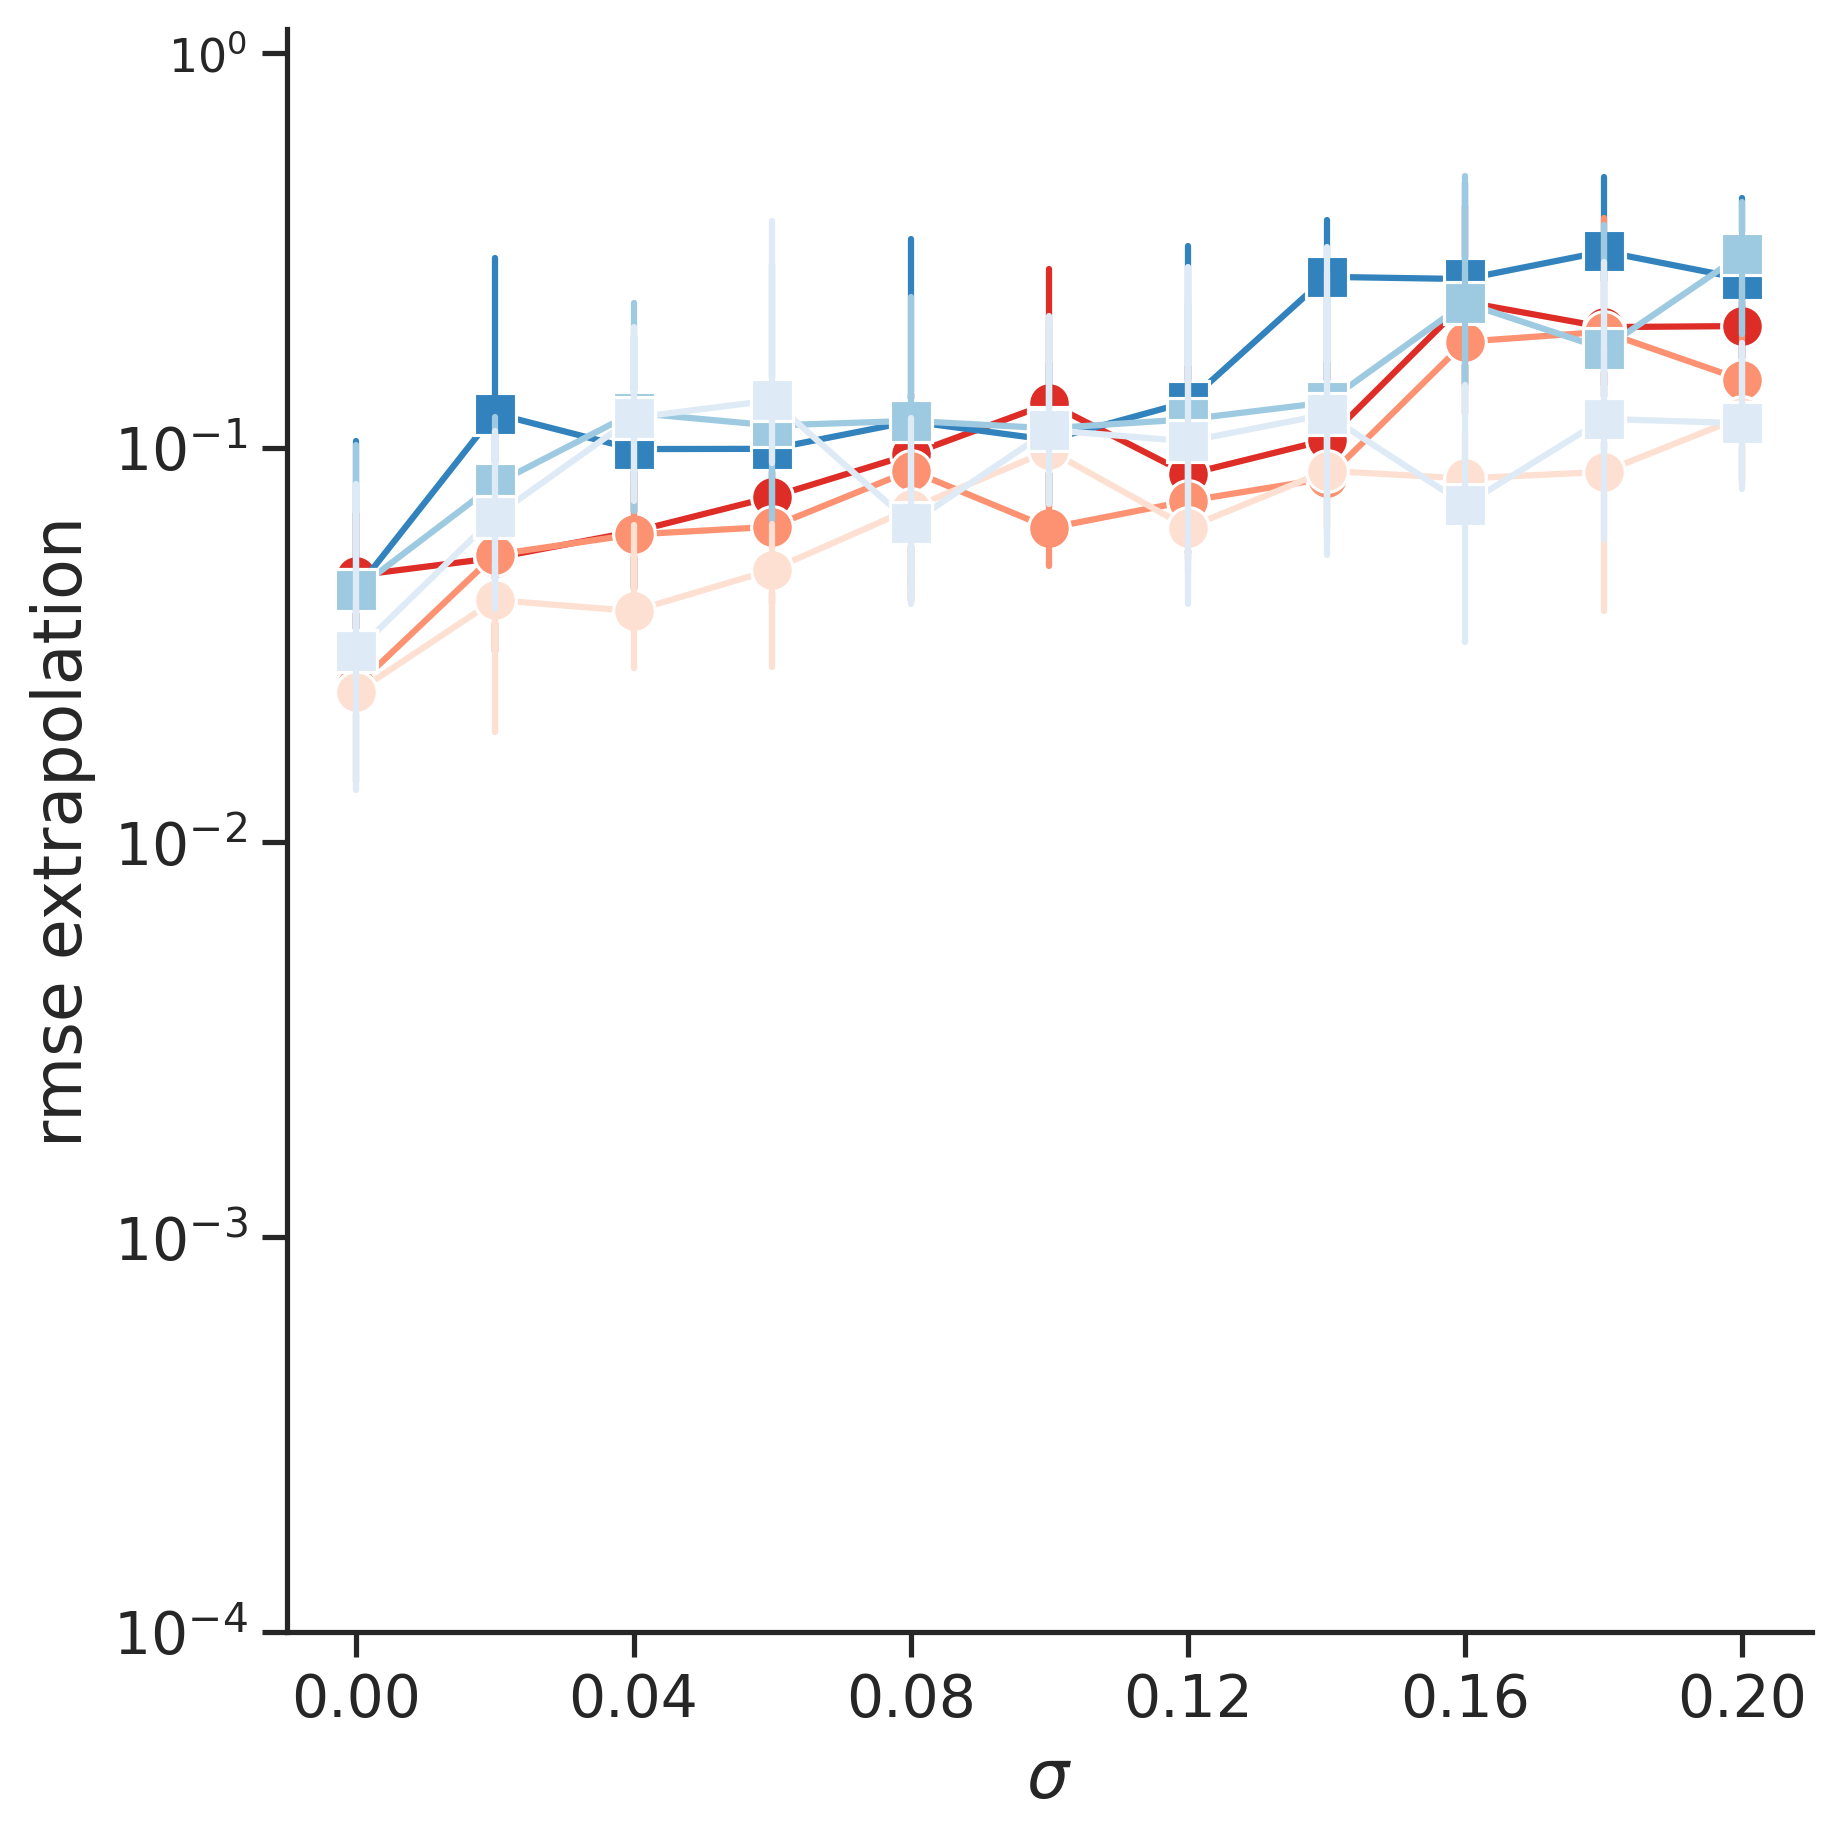

In [118]:
#Plot tanh extrapolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_tanh_extra[combined_tanh_extra['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value extrap.', hue='error extrap.', style='error extrap.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='extrapolations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#------------------------------------------------------------------------------------------------------------------------

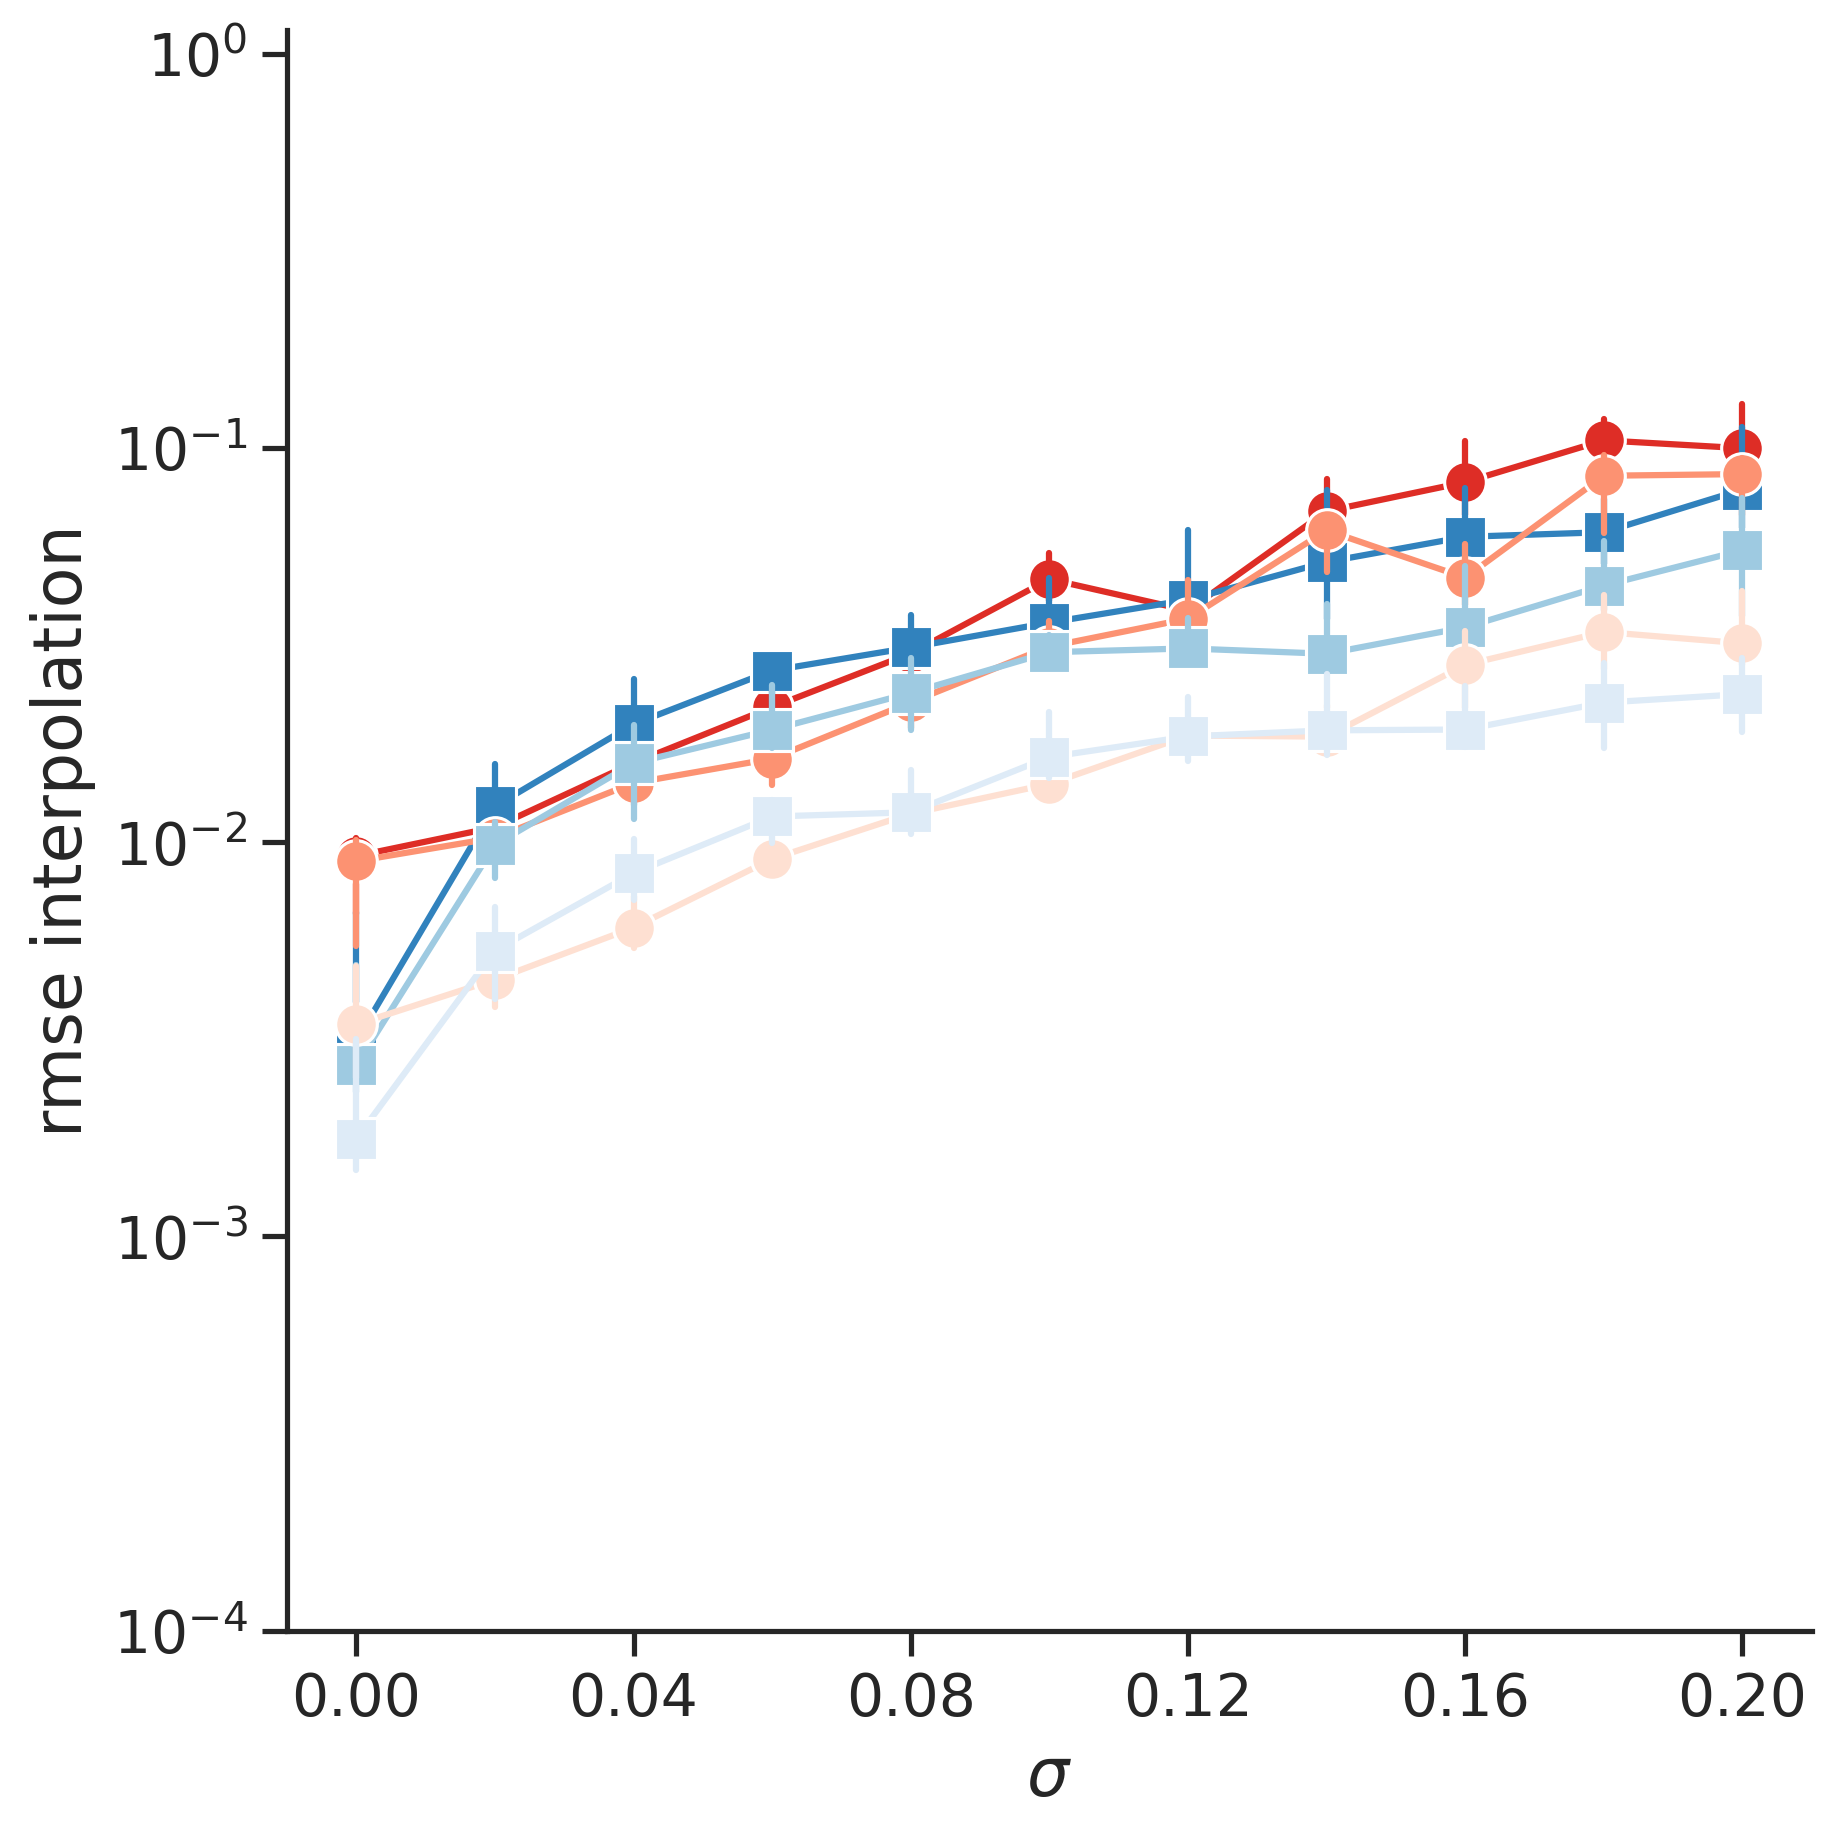

In [120]:
#Plot leaky interpolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_inter[combined_leaky_inter['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value interp.', hue='error interp.', style='error interp.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log");plt.minorticks_off()
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)


plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='interpolations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)

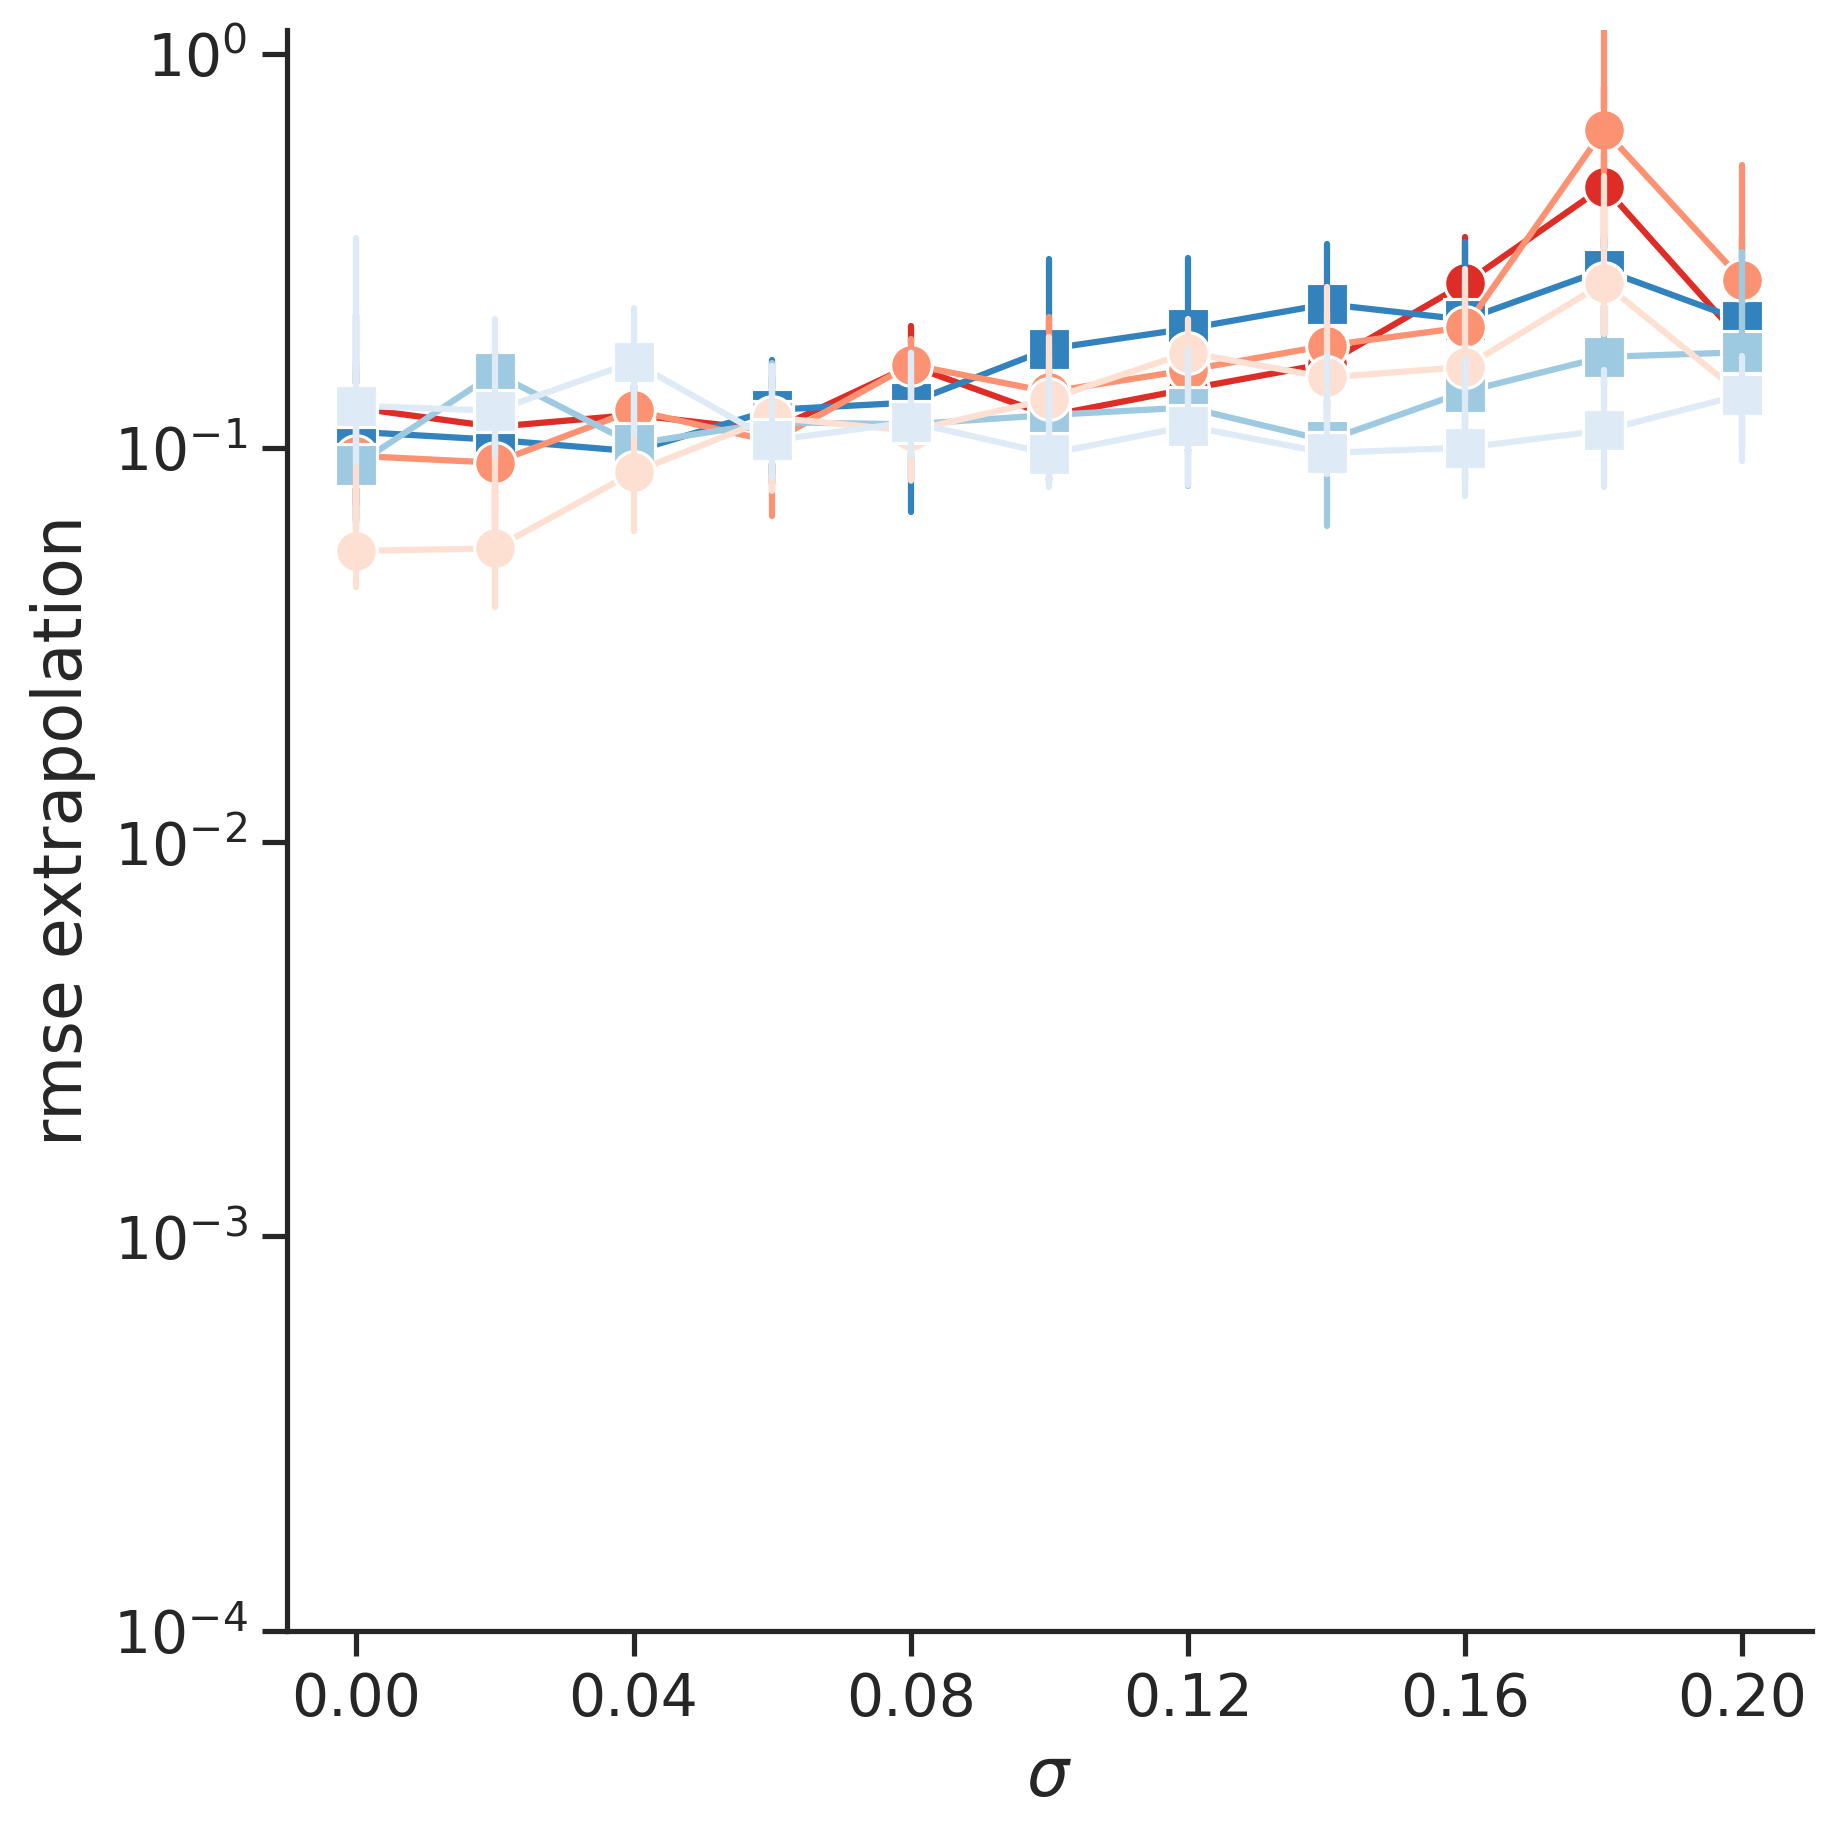

In [122]:
#Plot leaky extrapolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_extra[combined_leaky_extra['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value extrap.', hue='error extrap.', style='error extrap.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn'], markers['rmse_mdl']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log");plt.minorticks_off()
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

name_fig='extrapolations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
#------------------------------------------------------------------------------------------------------------------------